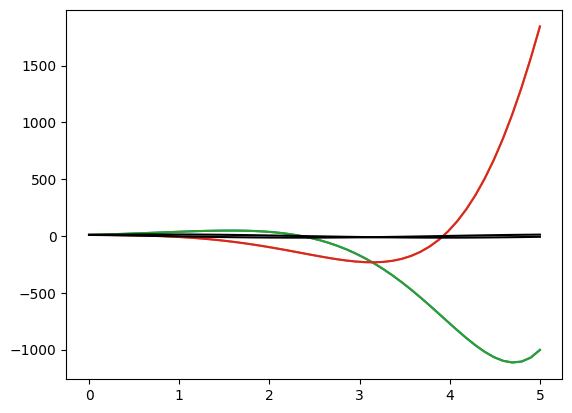

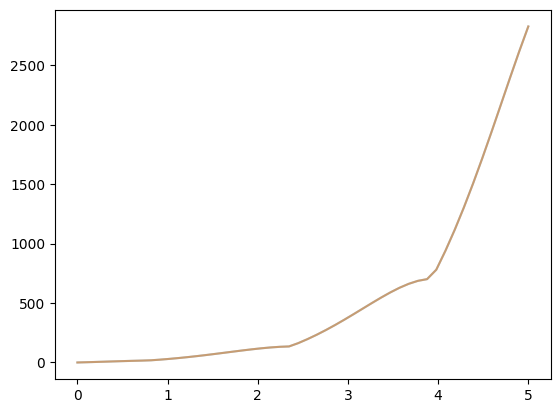

In [65]:
import jax
import jax.numpy as jnp

from probjax.utils.odeint import _odeint as odeint
from jax.experimental.ode import odeint as odeint2

A = jnp.array([[0., 1.], [-1., -0.]])
# Define the ODE
def f(t, x):
    return jnp.dot(A, x) + x 

def true_f(t):
    Phi = jax.scipy.linalg.expm(A * t)
    return Phi@x0

# Define the initial condition
x0 = jnp.ones((2,))*10

# Define the time points to evaluate
t = jnp.linspace(0., 5, 50)

# Solve the ODE
#x = odeint2(lambda x,t: f(t, x), x0, t, atol=1e-5, rtol=1e-4)
x = odeint(f, x0, t, method="exp_euler")

# Solve the ODE with dt
#with jax.disable_jit():
x2 = odeint(f, x0, t, method="dopri5", atol=1e-8, rtol=1e-8)

# Plot the solution
import matplotlib.pyplot as plt
plt.plot(t, x)
plt.plot(t, x2)
plt.plot(t, jax.vmap(true_f)(t), color="black")
plt.show()
plt.plot(t, jnp.abs(x - jax.vmap(true_f)(t)).sum(axis=-1), alpha=0.5)
plt.plot(t, jnp.abs(x2 - jax.vmap(true_f)(t)).sum(axis=-1), alpha=0.5)

In [70]:
dt = 0.5
H = jnp.block([[A, jnp.eye(A.shape[0])], [jnp.zeros_like(A), jnp.zeros_like(A)]])
eH = jax.scipy.linalg.expm(H*dt)

phi0 = eH[:A.shape[0], :A.shape[0]]
phi1 = eH[:A.shape[0], A.shape[0]:]
phi0@x0 + dt*phi1@(f(0., x0) - A@x0)

Array([16.579,  5.767], dtype=float32)

In [80]:
x0 +  dt*phi1@f(0, x0)

Array([14.794,  8.776], dtype=float32)

In [7]:
def linearized_f_sol(t,x):
    f_lin = jax.jacobian(f, argnums=1)(t, x)
    return jax.scipy.linalg.expm(A * t)@x 

In [19]:
f_lin = jax.jacobian(f, argnums=1)

In [51]:
J

In [62]:
%%timeit
jax.scipy.linalg.expm(jnp.eye(200))

The slowest run took 8.85 times longer than the fastest. This could mean that an intermediate result is being cached.
7.04 ms ± 8.41 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [63]:
%%timeit
jnp.exp(jnp.ones(200))

100 µs ± 590 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [28]:
from probjax.utils.odeint import get_step_fn

step_fn = get_step_fn(method="dopri5")

dt = 0.5
f0 = f(0., x0)
y0 = x0
y1, f1, (y1_error,k) = step_fn(f, jnp.array([0.]), y0, f0, jnp.array([dt]))

In [29]:
def fit_4th_order_polynomial(y0, y1, y_mid, dy0, dy1, dt):
  dt = dt.astype(y0.dtype)
  a = -2.*dt*dy0 + 2.*dt*dy1 -  8.*y0 -  8.*y1 + 16.*y_mid
  b =  5.*dt*dy0 - 3.*dt*dy1 + 18.*y0 + 14.*y1 - 32.*y_mid
  c = -4.*dt*dy0 +    dt*dy1 - 11.*y0 -  5.*y1 + 16.*y_mid
  d = dt * dy0
  e = y0
  return a, b, c, d, e

In [1]:
def fit_3rd_order_polynomial(y0, y1, dy0, dy1, dt):
    dt = dt.astype(y0.dtype)
    d = y0
    c = dy0 * dt
    b = (-2/3 *c - d/dt + y1/dt - dy1/3) * dt**2
    a = (y1 - b*dt**2 - c*dt - d)
    
    return a, b, c, d



a,b,c,d = fit_3rd_order_polynomial(y0, y1, f0, f1, jnp.array([0.01]))

vals = jax.vmap(jnp.polyval, in_axes=(None, 0))(jnp.vstack([a,b,c,d]), jnp.linspace(0., 1., 100))
plt.plot(vals)
plt.plot(y0, "o")
plt.plot(jnp.ones(2)*100,y1, "o")

NameError: name 'y0' is not defined

In [ ]:
jnp.polyval(jnp.asarray([a,b,c,d]), 0.01)

In [ ]:
a,b,c,d,e = fit_4th_order_polynomial(y0, y1, 0.5*(y0 + y1), f0, f1, jnp.array([0.01]))

vals = jax.vmap(jnp.polyval, in_axes=(None, 0))(jnp.vstack([a,b,c,d,e]), jnp.linspace(0., 1., 100))
plt.plot(vals)
plt.plot(y0, "o")
plt.plot(jnp.ones(2)*100,y1, "o")

In [ ]:
?jnp.polyfit

In [ ]:
from probjax.core import inverse, inverse_and_logabsdet

@jax.vmap
def g(x0):
    ys = odeint(f, x0, t)
    y1 = ys[-1]
    return y1

x = jnp.ones((10, 2))
y1 = g(x)
g_inv = inverse_and_logabsdet(g)

jaxpr = jax.make_jaxpr(g)(x)

In [ ]:
y = g(x)
x, det = g_inv(y)

In [ ]:
x

In [ ]:
jax.lax.dynamic_slice(jnp.arange(0, 10), (2,), (4,))

In [ ]:
f(x0, t[0])

In [ ]:
# def _inv_logdet_odeint(drift, y0, ts, *args, **kwargs):
#     drift_jac = jax.jacobian(drift, argnums=1)

#     def aug_drift(t, x, *args):
#         print("X",x.shape)
#         x = x[:-1]
#         x_new = drift(t, x, *args)
#         jac = drift_jac(t, x, *args)
#         print(jac.shape)
#         if jac.ndim > 2:
#             logdet_new = jnp.diagonal(jac, axis1=-2, axis2=-1).sum().reshape((1,))
#         else:
#             logdet_new = jac.sum().reshape((1,))

#         return jnp.concatenate([x_new, logdet_new])

#     y0_extended = jnp.concatenate([y0, jnp.zeros((1,))])
#     print(y0_extended.shape)
#     ys_extended = odeint(aug_drift, y0_extended, ts, *args, **kwargs)
#     ys = ys_extended[:, :-1]
#     logdet = ys_extended[-1, -1]

#     return ys, logdet

# with jax.disable_jit():
#     _inv_logdet_odeint(f, x0, t, method="euler")

In [ ]:
ys = odeint(f, x0*1e-20, t[::-1], method="heun_euler")

plt.plot(t, ys[::-1])

# ys = odeint(lambda x,t : f(-x, t), x0*1e-20, t, method="rk3(2)")
# plt.plot(t, ys)

In [ ]:
from jax import lax
from typing import Callable, Tuple, Union
from jax import Array

def explicit_stochastic_runge_kutta_step(
    drift: Callable,
    diffusion: Callable,
    t0: Array,
    y0: Array,
    f0: Array,
    g0: Array,
    dt: Array,
    dWt: Array,
    dWtdWs: Array,
    c0: Array,
    c1: Array,
    A0: Array,
    A1: Array,
    B0: Array,
    B1: Array,
    b_sol: Array,
    gamma0: Array,
    gamma1: Array,
    b_error: Array,
    order: int,
):
    def body_fun(i, k1, k2):
        ti1 = t0 + dt * c0[i - 1]
        ti2 = t0 + dt * c1[i - 1]

        yi1 = y0 + dt.astype(f0.dtype) * jnp.dot(A0[i - 1, :], k1) + dWt * jnp.dot(B1[i - 1, :], k2)
        yi2 = y0 + dt.astype(f0.dtype) * jnp.dot(A1[i - 1, :], k1) + jnp.sqrt(dt) * jnp.dot(B1[i - 1, :], k2)

        ft = drift(yi1, ti1)
        gt = diffusion(yi2, ti2)
        return k1.at[i, :].set(ft), k2.at[i, :].set(gt)

    k1 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k2 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k1,k2 = lax.fori_loop(1, order, body_fun, k1, k2)

    y1 = y0 + dt.astype(f0.dtype) * jnp.dot(b_sol, k1) + dWt * jnp.dot(gamma0, k2) + dWtdWs * jnp.dot(gamma1, k2)
    f1 = k1[-1]
    g1 = k2[-1]

    if b_error is None:
        y1_error = None
    else:
        raise NotImplementedError

    return y1, f1,g1, (y1_error, k1,k2)

In [ ]:
# odeint for all methods
from probjax.utils.odeint import odeint, get_methods

METHODS = get_methods()

for m in METHODS:
    print(m)
    #with jax.disable_jit():
    x = odeint(f, x0, t, method=m)
    
    plt.plot(t, x, label=m, alpha=0.5)
    plt.plot(jnp.linspace(0, 10, 10000), odeint(f, x0, jnp.linspace(0, 10, 10000), method="rk4"), color="black", lw=2, linestyle="--")
    plt.show()



plt.legend(METHODS + ["True"])

In [ ]:
def f(x):
    return x**2 - 2

In [ ]:
jnp.finfo(jnp.float32).eps

In [ ]:
from jax import lax
from functools import partial

METHODS = {}


c0 = jnp.array([0., 1.])
A0 = jnp.array([[0., 0.], [1., 0.]])
b_sol = jnp.array([0.5, 0.5])
b_error = jnp.array([1., 0.])

@partial(jax.jit, static_argnums=(0,))
def runge_kutta_step(func, y0, f0, t0, dt, c, A, b_sol, b_error, order=2):
  # Dopri5 Butcher tableaux

  def body_fun(i, k):
    ti = t0 + dt * c[i-1]
    yi = y0 + dt.astype(f0.dtype) * jnp.dot(A[i-1, :], k)
    ft = func(yi, ti)
    return k.at[i, :].set(ft)

  k = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
  k = lax.fori_loop(1, order, body_fun, k)

  y1 = dt.astype(f0.dtype) * jnp.dot(b_sol, k) + y0
  y1_error = dt.astype(f0.dtype) * jnp.dot(b_error, k)
  f1 = k[-1]
  return y1, f1, y1_error, k

In [ ]:
jnp.linalg.is_tril(A0)

In [ ]:
%%timeit
runge_kutta_step(f, jnp.array([1.]), jnp.array([1.]), jnp.array([0.]), jnp.array([1.]), alpha, beta, c_sol, c_error)

In [ ]:
@partial(jax.jit, static_argnums=(0,))
def _heun_step(_f, t0, y0, dt):
    half_dt = dt / 2
    k1 = _f(t0, y0)
    k2 = _f(t0 + half_dt, y0 + half_dt * k1)
    return y0 + (k1 + k2)/2 * dt

In [ ]:
%%timeit
_heun_step(f, jnp.array([0.]), jnp.array([1.]), jnp.array([1.]))

In [ ]:
def newton_raphson(f, x0, tol=1e-6, max_iter=50):
    """
    Newton-Raphson root-finding algorithm for a vector-valued function.
    
    Args:
    - f: A function that takes a vector x and returns a vector of the same shape.
    - x0: Initial guess for the root.
    - tol: Tolerance for stopping criterion (default: 1e-6).
    - max_iter: Maximum number of iterations (default: 100).
    
    Returns:
    - x: The estimated root of the function.
    """
    x = x0

    f_jax = jax.jacobian(f)

    def scan_fn(carry, i):
        tol_reached, x = carry

        def true_fn(x):
            return x, jnp.inf

        def false_fn(x):
            y = f(x)
            J = f_jax(x)
            delta_x = jax.scipy.linalg.solve(J, -y)
            x = x + delta_x
            return x, jnp.linalg.norm(delta_x)
        
        
        x, delta_x = jax.lax.cond(tol_reached, true_fn, false_fn, x)
        tol_reached = delta_x < tol
        return (tol_reached, x), x
      
    
    tol_reached = False
    _, x = jax.lax.scan(scan_fn, (tol_reached, x), jnp.arange(max_iter))
    return x[-1]

newton_raphson(f, jnp.array([100.]))

In [ ]:
from probjax.utils.interpolation import linear_interpolation

jax.vmap(linear_interpolation(t, x))(jnp.array([0.5, 0.75])).shape

In [ ]:

from functools import partial
from typing import Optional, Tuple, Union
from jax import Array 
from jaxtyping import Float


jax.jit
def _generate_grid(ts: jnp.ndarray, dt_max: Optional[float] = None):
    """Generate a grid of time points that satisfy the minimum dt

    Args:
        ts (jnp.ndarray): Time points.
        max_dt (Optional[float], optional): Maximum dt. Defaults to None.

    Returns:
        jnp.ndarray: Grid of time points.
    """
    dts = ts[1:] - ts[:-1]
    dts_expension = jnp.ceil(dts / dt_max)

    def scan_fn(t_prev, dt):
        def true_fn(dt):
            return t_prev + dt
        
        def false_fn(dt):
            
            def cond_fn(t):
                return t < t_prev + dt
            
            def body_fn(t):
                return t + dt
            
            return jax.lax.while_loop(cond_fn, body_fn, t_prev)
        return t, grid
    
    _, grid = jax.lax.scan(scan_fn, (ts[0],), dts)
    

In [ ]:
dt_max = 0.1
ts = jnp.array([0.0, 0.1, 0.35,0.5])
dts  = ts[1:] - ts[:-1]

dts_extension = jnp.ceil(dts/dt_max)

dts_extension

In [ ]:
@jax.jit 
def f(ts):
    T_max = ts[-1]
    T_min = ts[0]
    ts = _generate_grid(ts, T_max, T_min, max_dt=0.1)

In [ ]:
f(t)

In [ ]:
ts.shape

In [ ]:
ts[:100]